In [2]:
!pip install pymongo


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pymongo import MongoClient
Client=MongoClient("mongodb://localhost:27017/")
Client.admin.command("ping")
print("connected to mongodb")

connected to mongodb


In [4]:
db=Client["schoolDB"]
students=db["students"]

In [25]:
students.delete_many({})
print("delete sucessfully")

delete sucessfully


In [26]:
result=students.insert_one({"name":"Aarav","age":21,"dept":"CSE","marks":85,"skills":["Python","Mongodb"],"city":"Hyderabad","fees":50000,"paid":30000})
print("inserted one row")

inserted one row


In [27]:
docs = [
    {"name": "Diya",  "age": 22, "dept": "ECE",  "marks": 72, "skills": ["c", "verilog"],          "city": "Chennai",   "fees":  45000, "paid": 45000},
    {"name": "Kabir", "age": 20, "dept": "CSE",  "marks": 91, "skills": ["java", "sql", "mongodb"],"city": "Hyderabad", "fees":  50000, "paid": 50000},
    {"name": "Meera", "age": 23, "dept": "MECH", "marks": 64, "skills": ["autocad"],               "city": "Pune",      "fees":  40000, "paid": 20000},
    {"name": "Rohan", "age": 21, "dept": "CSE",  "marks": 78, "skills": ["python", "sql"],         "city": "Chennai",   "fees":  50000, "paid": 40000},
    {"name": "Sana",  "age": 22, "dept": "ECE",  "marks": 88, "skills": ["python", "matlab"],      "city": "Hyderabad", "fees":  45000, "paid": 45000}
]
result = students.insert_many(docs)
print(f"Inserted {result}")

Inserted InsertManyResult([ObjectId('6aa27e8ce523b18b81ca3cb7'), ObjectId('6aa27e8ce523b18b81ca3cb8'), ObjectId('6aa27e8ce523b18b81ca3cb9'), ObjectId('6aa27e8ce523b18b81ca3cba'), ObjectId('6aa27e8ce523b18b81ca3cbb')], acknowledged=True)


In [28]:
#insert a student with your own name using `insert_one`
result=students.insert_one({"name":"Shivani","age":20,"dept":"EEE","marks":98,"skills":["Python","Mongodb","Postgres"],"city":"Kurnool","fees":45000,"paid":20000})
print("inserted")

inserted


In [18]:
#Print the names of all students from Chennai with marks above 70.
for s in students.find({"city":"Chennai","marks":{"$gt":70}}):
    print(s["name"])

Diya
Rohan


In [24]:
#3. Print only `name` and `skills` for students who know Python, sorted by name.
for s in students.find({"skills": {"$regex": "^python$", "$options": "i"}}).sort("name",1):
    print(s["name"],s["skills"])

Aarav ['Python', 'Mongodb']
Rohan ['python', 'sql']
Sana ['python', 'matlab']
Shivani ['Python', 'Mongodb', 'Postgres']


In [21]:
!pip install pandas matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd

df = pd.DataFrame(list(students.find({}, {"_id": 0, "name": 1, "dept": 1, "marks": 1, "city": 1,"skills":1,"fees":1,"paid":1})))
df

,name,dept,marks,skills,city,fees,paid
0,Aarav,CSE,85,"[Python, Mongodb]",Hyderabad,50000,32000
1,Diya,ECE,72,"[c, verilog]",Chennai,45000,45000
2,Kabir,CSE,91,"[java, sql, mongodb]",Hyderabad,50000,52000
3,Meera,MECH,64,[autocad],Pune,40000,20000
4,Rohan,CSE,78,"[python, sql]",Chennai,50000,40000
5,Sana,ECE,88,"[python, matlab]",Hyderabad,45000,47000
6,Shivani,EEE,98,"[Python, Mongodb, Postgres]",Kurnool,45000,20000


In [30]:
#4. Add 2000 to `fees.paid` for every student from Hyderabad (`update_many` + `$inc`).
students.update_many({"city":"Hyderabad"},{"$inc":{"paid":2000}})

UpdateResult({'n': 3, 'nModified': 3, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [ ]:
#5. Write an aggregation that shows the number of students per **city**.
result= [
    {"$group": {
        "_id": "$city",
        "count": {"$sum": 1}
    }}]
print

In [36]:
for row in students.aggregate(result):
    print(row["_id"],row["count"])

Kurnool 1
Pune 1
Hyderabad 3
Chennai 2


Matplotlib is building the font cache; this may take a moment.


      name  marks
0    Aarav     85
1     Diya     72
2    Kabir     91
3    Meera     64
4    Rohan     78
5     Sana     88
6  Shivani     98


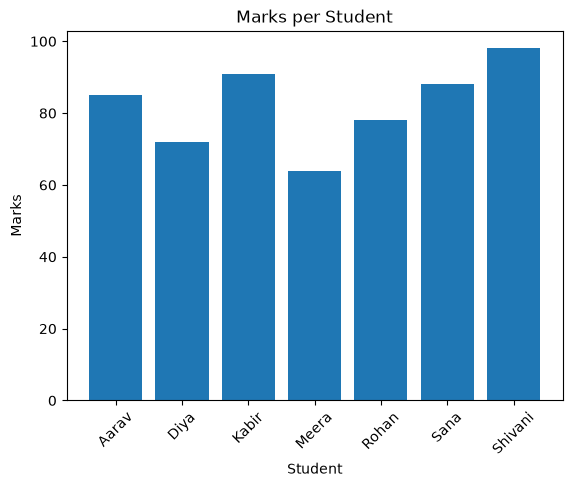

In [37]:
#6. Load all students into a pandas DataFrame and plot a bar chart of marks per student.

import pandas as pd
import matplotlib.pyplot as plt

data = list(students.find({}, {"_id": 0, "name": 1, "marks": 1}))

df = pd.DataFrame(data)

print(df)

plt.bar(df["name"], df["marks"])
plt.xlabel("Student")
plt.ylabel("Marks")
plt.title("Marks per Student")
plt.xticks(rotation=45)
plt.show()

In [39]:
db=Client["schoolDB"]
departments=db["departments"]

In [40]:
import pandas as pd

df = pd.DataFrame(list(departments.find({}, {"_id": 0, "code":1,"fullName":1,"hod":1})))
df

,code,fullName,hod
0,CSE,Computer Science,Dr. Rao
1,ECE,Electronics,Dr. Iyer
2,MECH,Mechanical,Dr. Khan


In [41]:


result = students.aggregate([
    {
        "$lookup": {
            "from": "departments",
            "localField": "dept",
            "foreignField": "code",
            "as": "department"
        }
    },
    {
        "$unwind": "$department"
    },
    {
        "$project": {
            "_id": 0,
            "name": 1,
            "departmentName": "$department.fullName"
        }
    }
])

for s in result:
    print(f"{s['name']} → {s['departmentName']}")

Aarav → Computer Science
Diya → Electronics
Kabir → Computer Science
Meera → Mechanical
Rohan → Computer Science
Sana → Electronics


In [43]:
Client.close()
print("Connection closed")

Connection closed
